# Notebook 14 — Real-data audit and event alignment

This notebook audits the fixed USD/JPY spot and option-IV sources and builds a descriptive event-alignment checkpoint for later work. It does not estimate causality or forecasts, and it does not modify source data.

## 1. Purpose and boundaries

Canonical inputs remain the daily Bloomberg bid/ask/last spot workbook, the 1M ATM sheet from the all-tenors ATM workbook, FOMC upper-bound decisions, and consolidated BoJ daily decisions. All outputs below are derived checkpoints only.

## 2. Imports and paths

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA = (ROOT / '../../DATA').resolve()
OUT = ROOT / 'notebook14_results'
OUT.mkdir(exist_ok=True)

assert DATA.is_dir(), f'Missing DATA directory: {DATA}'

P = {
    'spot': DATA / 'Currency Daily BidAskLast.xlsx',
    'mid': DATA / 'daily_mid.csv',
    'atm': DATA / 'ATM_Volatility_-_all_currencies_diff_tenors.xlsx',
    'short': DATA / 'imp vol diff tenors.xlsx',
    'conflict': DATA / 'imp vol daily 5 years.xlsx',
    'rr': DATA / '25R - all currencies diff tenors.xlsx',
    'bf': DATA / '25B - all currencies diff tenors.xlsx',
    'fomc': DATA / 'calendar_events.xlsx',
    'boj': DATA / 'boj_monetary_policy_meetings_2015_2026.csv',
}
assert all(path.exists() for path in P.values())

excluded = {
    'Currency Hourly BidAskLast.xlsx': 'hourly excluded',
    'hourly_mid.csv': 'hourly excluded',
    'mxn pln daily.xlsx': 'other pair',
    'mxn pln hourly.xlsx': 'other pair/hourly',
    'mxn pln hourly1.xlsx': 'other pair/hourly',
    'EUR_PLN Historical Data.csv': 'other pair',
    'EUR_PLN Historical Data 2006_2026.csv': 'other pair',
}


## 3. Source inventory

The inventory is written after each selected primary source has been read. Secondary files are retained only for reconciliation; excluded files retain their prior reasons.

## 4. USD/JPY spot audit

In [2]:
# The workbook has a six-row preamble; USDJPY bid, ask and last are H:J.
spot_raw = pd.read_excel(P['spot'], sheet_name='Sheet1', skiprows=6, header=0)
spot = spot_raw.iloc[:, [0, 7, 8, 9]].copy()
spot.columns = ['date', 'spot_bid', 'spot_ask', 'spot_last']
spot['date'] = pd.to_datetime(spot['date'], errors='coerce')
for column in ['spot_bid', 'spot_ask', 'spot_last']:
    spot[column] = pd.to_numeric(spot[column], errors='coerce')
spot = spot.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
spot['spot_mid'] = (spot['spot_bid'] + spot['spot_ask']) / 2
spot['spot_crossed_quote_flag'] = spot['spot_bid'] > spot['spot_ask']
spot['spot_nonpositive_flag'] = spot[['spot_bid', 'spot_ask', 'spot_last']].le(0).any(axis=1)
spot['spot_missing_flag'] = spot[['spot_bid', 'spot_ask', 'spot_last']].isna().any(axis=1)
spot['previous_native_spot_date'] = spot['date'].shift(1)
spot['spot_log_return_native'] = np.log(spot['spot_mid'] / spot['spot_mid'].shift(1))

mid = pd.read_csv(P['mid'])
mid_date_column = next(c for c in mid if c.lower() in {'date', 'dates'})
mid = mid.rename(columns={mid_date_column: 'date'})
mid['date'] = pd.to_datetime(mid['date'], errors='coerce')
mid_check = spot[['date', 'spot_mid']].merge(mid[['date', 'USDJPY']], on='date')
mid_check['difference'] = mid_check['spot_mid'] - mid_check['USDJPY']
mid_check['mid_match'] = np.isclose(mid_check['spot_mid'], mid_check['USDJPY'])

spot_audit = pd.DataFrame([{
    'sample_start': spot['date'].min(),
    'sample_end': spot['date'].max(),
    'observations': len(spot),
    'duplicates': int(spot['date'].duplicated().sum()),
    'missing_rows': int(spot['spot_missing_flag'].sum()),
    'crossed_quotes': int(spot['spot_crossed_quote_flag'].sum()),
    'nonpositive_quotes': int(spot['spot_nonpositive_flag'].sum()),
    'weekends': int(spot['date'].dt.dayofweek.ge(5).sum()),
    'gaps_over_3_days': int(spot['date'].diff().dt.days.gt(3).sum()),
    'mid_validation_common_dates': len(mid_check),
    'mid_validation_mismatches': int((~mid_check['mid_match']).sum()),
    'mid_last_mean_abs_difference': float((spot['spot_mid'] - spot['spot_last']).abs().mean()),
}])
spot_audit.to_csv(OUT / 'usdjpy_spot_quality_audit.csv', index=False)


## 5. ATM IV audit and source reconciliation

Dates from secondary workbooks are parsed with their observed ISO date format, rather than inferred, so that reconciliation is warning-free.

In [3]:
def read_option_workbook(path, sheets, expected_tickers, value_column):
    frames = []
    for tenor in sheets:
        raw = pd.read_excel(path, sheet_name=tenor, header=None)
        ticker = str(raw.iloc[1, 5])
        assert ticker == expected_tickers[tenor], f'Unexpected ticker in {path.name}/{tenor}: {ticker}'
        frame = pd.DataFrame({
            'date': pd.to_datetime(raw.iloc[3:, 4], errors='coerce'),
            value_column: pd.to_numeric(raw.iloc[3:, 5], errors='coerce'),
        }).dropna(subset=['date'])
        frame['currency_pair'] = 'USDJPY'
        frame['tenor'] = tenor
        frame['ticker'] = ticker
        frame['source_workbook'] = path.name
        frame['source_sheet'] = tenor
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

def read_secondary_iv(path, sheet_name=None):
    raw = pd.read_excel(path, sheet_name=0 if sheet_name is None else sheet_name, header=None)
    date_text = raw.iloc[:, 0].astype(str).str.slice(0, 10)
    return pd.DataFrame({
        'date': pd.to_datetime(date_text, format='%Y-%m-%d', errors='coerce'),
        'secondary_value': pd.to_numeric(raw.iloc[:, 1], errors='coerce'),
    }).dropna(subset=['date'])

atm_tickers = {tenor: f'USDJPYV{tenor} BGN Curncy' for tenor in ['1W', '2W', '1M', '2M', '3M', '6M', '1Y']}
atm_tickers['1D'] = 'USDJPYVON BGN Curncy'
atm = read_option_workbook(P['atm'], ['1D', '1W', '2W', '1M', '2M', '3M', '6M', '1Y'], atm_tickers, 'atm_iv')
a1 = atm.loc[atm['tenor'].eq('1M')].copy().rename(columns={'atm_iv': 'atm_1m_iv'})
a1 = a1.sort_values('date').reset_index(drop=True)
a1['previous_native_iv_date'] = a1['date'].shift(1)
a1['atm_1m_div_native'] = a1['atm_1m_iv'].diff()
a1['atm_1m_dlogiv_native'] = np.log(a1['atm_1m_iv'] / a1['atm_1m_iv'].shift(1))
atm.to_csv(OUT / 'usdjpy_atm_tidy.csv', index=False)

# The short-tenor workbook has named tenor sheets. Reconcile its actual 1M sheet only.
short_1m = read_secondary_iv(P['short'], sheet_name='1month')
five_year_1m = read_secondary_iv(P['conflict'])

def reconcile_atm_source(label, secondary):
    merged = a1[['date', 'atm_1m_iv']].merge(secondary, on='date')
    merged['difference'] = merged['atm_1m_iv'] - merged['secondary_value']
    merged['exact_match'] = np.isclose(merged['difference'], 0)
    conflicts = merged.loc[~merged['exact_match']]
    return {
        'comparison': label,
        'common_dates': len(merged),
        'exact_matches': int(merged['exact_match'].sum()),
        'conflicting_date_count': len(conflicts),
        'max_abs_difference': float(merged['difference'].abs().max()),
        'conflicting_dates': ';'.join(conflicts['date'].dt.strftime('%Y-%m-%d')),
        'canonical_values_at_conflict': ';'.join(conflicts['atm_1m_iv'].astype(str)),
        'secondary_values_at_conflict': ';'.join(conflicts['secondary_value'].astype(str)),
    }

short_1m_reconciliation = reconcile_atm_source('short_1month', short_1m)
five_year_reconciliation = reconcile_atm_source('conflicting_5year', five_year_1m)
short_1m_conflicts = short_1m_reconciliation['conflicting_date_count']
shorter_1m_exact_matches = short_1m_reconciliation['exact_matches']
five_year_conflicts = five_year_reconciliation['conflicting_date_count']
total_secondary_atm_conflicts = short_1m_conflicts + five_year_conflicts

assert short_1m_conflicts == 0
assert shorter_1m_exact_matches == 1305
assert total_secondary_atm_conflicts == 1

reconciliation_rows = [short_1m_reconciliation, five_year_reconciliation]
reconciliation = pd.DataFrame(reconciliation_rows)
reconciliation.to_csv(OUT / 'atm_source_reconciliation.csv', index=False)


## 6. RR and BF audit

In [4]:
rr_tickers = {tenor: f'USDJPY25R{tenor} BGN Curncy' for tenor in ['1M', '3M', '6M', '1Y']}
bf_tickers = {tenor: f'USDJPY25B{tenor} BGN Curncy' for tenor in ['1M', '3M', '6M']}
rr = read_option_workbook(P['rr'], list(rr_tickers), rr_tickers, 'risk_reversal')
bf = read_option_workbook(P['bf'], list(bf_tickers), bf_tickers, 'butterfly')
rr.to_csv(OUT / 'usdjpy_25d_rr_tidy.csv', index=False)
bf.to_csv(OUT / 'usdjpy_25d_bf_tidy.csv', index=False)

bf_1w_ticker = str(pd.read_excel(P['bf'], sheet_name='1W', header=None).iloc[1, 5])
anomaly = pd.DataFrame([{
    'source_workbook': P['bf'].name,
    'source_sheet': '1W',
    'observed_ticker': bf_1w_ticker,
    'warning': 'Misfiled 1W 25R ticker; excluded from butterfly data.',
}])
anomaly.to_csv(OUT / 'option_source_anomalies.csv', index=False)


## 7. FOMC cleaning

Only the upper-bound FOMC decision is retained.

In [5]:
with pd.ExcelFile(P['fomc']) as workbook:
    fomc_sheet = workbook.sheet_names[0]
fomc_raw = pd.read_excel(P['fomc'], sheet_name=fomc_sheet).reset_index(names='original_row_number')
fomc = fomc_raw.loc[fomc_raw['Event'].eq('FOMC Rate Decision (Upper Bound)')].copy()
fomc['original_row_number'] += 2
fomc['raw_naive_timestamp'] = pd.to_datetime(fomc['Date Time'])
fomc['local_timestamp'] = fomc['raw_naive_timestamp'].dt.tz_localize('Europe/London')
fomc['utc_timestamp'] = fomc['local_timestamp'].dt.tz_convert('UTC')
fomc['local_event_date'] = fomc['local_timestamp'].dt.tz_localize(None).dt.normalize()
fomc['event_id'] = 'FOMC_' + fomc['local_event_date'].dt.strftime('%Y%m%d')
fomc['central_bank'] = 'FOMC'
fomc['consolidated_from_duplicates'] = False
fomc_clean = fomc[['event_id', 'central_bank', 'raw_naive_timestamp', 'local_timestamp', 'utc_timestamp', 'local_event_date', 'Country Code', 'Event', 'Survey', 'Actual', 'Prior', 'Revised', 'Relevance', 'Ticker', 'original_row_number', 'consolidated_from_duplicates']]
fomc_clean.to_csv(OUT / 'fomc_decisions_clean.csv', index=False)


## 8. BoJ cleaning and duplicate consolidation

Multiple reported times on one local decision date are consolidated to one daily BoJ decision.

In [6]:
boj_raw = pd.read_csv(P['boj']).reset_index(names='original_row_number')
boj_event_type_audit = (
    boj_raw.groupby('Event', dropna=False)
    .size()
    .rename('raw_row_count')
    .reset_index()
)
boj_event_type_audit.to_csv(OUT / 'boj_event_type_audit.csv', index=False)

decision_label = 'BoJ Interest Rate Decision'
boj_decision_raw = boj_raw.loc[
    boj_raw['Event'].astype(str).str.strip().eq(decision_label)
].copy()
boj_nondecision_raw = boj_raw.loc[
    ~boj_raw['Event'].astype(str).str.strip().eq(decision_label)
].copy()
assert len(boj_raw) == 108
assert len(boj_decision_raw) == 105
assert len(boj_nondecision_raw) == 3
assert boj_nondecision_raw['Event'].eq('BoJ Monetary Policy Meeting Minutes').all()

# Construct authoritative timestamps from local Japanese date and reported JST time.
boj_decision_raw['raw_naive_timestamp'] = pd.to_datetime(
    boj_decision_raw['Date (dd/mm/yyyy)'].astype(str) + ' ' + boj_decision_raw['Time (JST)'].astype(str),
    format='%d/%m/%Y %H:%M',
    errors='coerce',
)
assert boj_decision_raw['raw_naive_timestamp'].notna().all()
boj_decision_raw['local_timestamp'] = boj_decision_raw['raw_naive_timestamp'].dt.tz_localize('Asia/Tokyo')
boj_decision_raw['utc_timestamp'] = boj_decision_raw['local_timestamp'].dt.tz_convert('UTC')
boj_decision_raw['local_event_date'] = boj_decision_raw['local_timestamp'].dt.tz_localize(None).dt.normalize()
duplicate_decision_date_count = int(
    boj_decision_raw.groupby('local_event_date').size().gt(1).sum()
)
assert boj_decision_raw['local_event_date'].nunique() == 99
assert duplicate_decision_date_count == 6

actual_placeholders = {'', '-', '--', '–', '—', 'N/A', 'NA'}
actual_placeholder_upper = {value.upper() for value in actual_placeholders}

def reported_actual(value):
    if pd.isna(value):
        return False
    return str(value).strip().upper() not in actual_placeholder_upper

boj_rows = []
for event_date, group in boj_decision_raw.groupby('local_event_date', sort=True):
    ordered = group.sort_values('local_timestamp')
    row = ordered.iloc[0].copy()
    row['event_id'] = 'BOJ_' + event_date.strftime('%Y%m%d')
    row['central_bank'] = 'BoJ'
    row['duplicate_row_count'] = len(ordered)
    row['all_reported_times_jst'] = ';'.join(ordered['Time (JST)'].astype(str))
    row['earliest_local_timestamp'] = ordered['local_timestamp'].min()
    row['latest_local_timestamp'] = ordered['local_timestamp'].max()
    valid_actual = [str(value).strip() for value in ordered['Actual'] if reported_actual(value)]
    row['Actual'] = valid_actual[0] if valid_actual else np.nan
    row['consolidated_from_duplicates'] = len(ordered) > 1
    boj_rows.append(row)
boj = pd.DataFrame(boj_rows)
boj_clean = boj[['event_id', 'central_bank', 'raw_naive_timestamp', 'local_timestamp', 'utc_timestamp', 'local_event_date', 'Country Code', 'Event', 'Actual', 'Previous', 'Consensus', 'original_row_number', 'duplicate_row_count', 'all_reported_times_jst', 'earliest_local_timestamp', 'latest_local_timestamp', 'consolidated_from_duplicates']]
boj_clean.to_csv(OUT / 'boj_decisions_clean.csv', index=False)
boj_clean[['event_id', 'local_event_date', 'duplicate_row_count', 'all_reported_times_jst', 'earliest_local_timestamp', 'latest_local_timestamp']].to_csv(OUT / 'boj_duplicate_resolution.csv', index=False)
assert len(boj_clean) == 99
assert boj_clean['event_id'].is_unique
assert boj_clean['local_event_date'].is_unique
assert boj_clean['Event'].eq(decision_label).all()

fomc_events = fomc_clean.rename(columns={'Country Code': 'country_code', 'Event': 'event', 'Survey': 'survey', 'Actual': 'actual', 'Prior': 'previous', 'Revised': 'revised', 'Relevance': 'relevance', 'Ticker': 'ticker'})
boj_events = boj_clean.rename(columns={'Country Code': 'country_code', 'Event': 'event', 'Actual': 'actual', 'Previous': 'previous', 'Consensus': 'survey'})
events = pd.concat([fomc_events, boj_events], ignore_index=True, sort=False)
events.to_csv(OUT / 'central_bank_decisions_clean.csv', index=False)
assert not events['event'].astype(str).str.contains('Minutes', case=False, na=False).any()
assert events['event_id'].is_unique
assert len(fomc_clean) == 40
assert len(boj_clean) == 99
assert len(events) == 139


## 9. Canonical common panel

Native transformations remain explicitly labelled. The unqualified transformations are recalculated after the spot–IV merge, with no filling or interpolation.

In [7]:
panel = spot[['date', 'spot_bid', 'spot_ask', 'spot_last', 'spot_mid', 'spot_crossed_quote_flag', 'spot_nonpositive_flag', 'spot_missing_flag', 'previous_native_spot_date', 'spot_log_return_native']].merge(
    a1[['date', 'atm_1m_iv', 'previous_native_iv_date', 'atm_1m_div_native', 'atm_1m_dlogiv_native']],
    on='date',
    how='inner',
).sort_values('date').reset_index(drop=True)

panel['spot_log_return'] = np.log(panel['spot_mid'] / panel['spot_mid'].shift(1))
panel['spot_log_return_pct'] = 100 * panel['spot_log_return']
panel['atm_1m_div'] = panel['atm_1m_iv'].diff()
panel['atm_1m_dlogiv'] = np.log(panel['atm_1m_iv'] / panel['atm_1m_iv'].shift(1))
panel['panel_gap_calendar_days'] = panel['date'].diff().dt.days
panel['previous_common_panel_date'] = panel['date'].shift(1)
panel['native_common_transition_mismatch_flag'] = (
    panel['previous_native_spot_date'].notna()
    & panel['previous_common_panel_date'].notna()
    & panel['previous_native_spot_date'].ne(panel['previous_common_panel_date'])
)
native_common_transition_mismatches = int(panel['native_common_transition_mismatch_flag'].sum())
panel.to_csv(OUT / 'usdjpy_daily_spot_1m_atm_panel.csv', index=False)

crossed_spot_dates = set(spot.loc[spot['spot_crossed_quote_flag'], 'date'])
crossed_panel_dates = set(panel.loc[panel['spot_crossed_quote_flag'], 'date'])
assert len(panel) == 7922
assert crossed_spot_dates.issubset(crossed_panel_dates)
assert len(crossed_panel_dates) == 12
assert int(panel['spot_crossed_quote_flag'].sum()) == 12
assert int(panel['spot_nonpositive_flag'].sum()) == int(spot['spot_nonpositive_flag'].sum())
assert int(panel['spot_missing_flag'].sum()) == int(spot['spot_missing_flag'].sum())
assert panel['date'].min() == pd.Timestamp('1995-12-04')
assert panel['date'].max() == pd.Timestamp('2026-06-10')


## 10. Daily event alignment

Same-date alignment uses the first available observation on or after the decision date; next-observation alignment uses the observation strictly after the decision date. Both are retained because the daily IV fixing time is unresolved.

In [8]:
panel_dates = panel['date'].to_numpy(dtype='datetime64[ns]')

def align_events(convention):
    rows = []
    for _, event in events.iterrows():
        date = pd.Timestamp(event['local_event_date']).normalize()
        insertion = np.searchsorted(panel_dates, np.datetime64(date), side='left')
        same_date_exists = insertion < len(panel_dates) and pd.Timestamp(panel_dates[insertion]) == date
        if convention == 'same_date':
            index = insertion
        else:
            index = np.searchsorted(panel_dates, np.datetime64(date), side='right')
        outside = index >= len(panel_dates)
        aligned_date = pd.NaT if outside else pd.Timestamp(panel_dates[index])
        rows.append({
            'event_id': event['event_id'],
            'central_bank': event['central_bank'],
            'local_event_date': date,
            'local_timestamp': event['local_timestamp'],
            'utc_timestamp': event['utc_timestamp'],
            'aligned_market_date': aligned_date,
            'calendar_day_shift': np.nan if outside else (aligned_date - date).days,
            'trading_observation_shift': np.nan if outside else index - insertion,
            'same_date_data_existed': same_date_exists,
            'event_outside_panel': outside,
            'consolidated_from_duplicates': bool(event.get('consolidated_from_duplicates', False)),
            'event_time_index': np.nan if outside else index,
            'alignment_convention': convention,
        })
    return pd.DataFrame(rows)

alignment_same = align_events('same_date')
alignment_next = align_events('next_observation')
alignment_same.to_csv(OUT / 'event_alignment_same_date.csv', index=False)
alignment_next.to_csv(OUT / 'event_alignment_next_observation.csv', index=False)


## 11. Event-window and contamination construction

Contamination is event-level: another event's aligned age-zero index falls inside the current event's full window (−20…+10) or post window (0…+10). Those flags are calculated once per event and repeated across all 31 rows; contaminated events are retained.

In [9]:
WINDOW_AGES = range(-20, 11)

def ids_and_count(other_events):
    identifiers = ';'.join(other_events['event_id'].astype(str).tolist())
    return identifiers, len(other_events)

def build_event_windows(alignment):
    aligned = alignment.loc[~alignment['event_outside_panel']].copy()
    aligned['event_time_index'] = aligned['event_time_index'].astype(int)
    event_rows = []
    window_rows = []
    for _, event in aligned.iterrows():
        index = int(event['event_time_index'])
        others = aligned.loc[aligned['event_id'].ne(event['event_id'])]
        full_other = others.loc[others['event_time_index'].between(index - 20, index + 10)]
        post_other = others.loc[others['event_time_index'].between(index, index + 10)]
        full_ids, full_count = ids_and_count(full_other)
        post_ids, post_count = ids_and_count(post_other)
        complete_pre = index - 20 >= 0
        complete_post = index + 10 < len(panel)
        complete_window = complete_pre and complete_post
        event_fields = {
            'complete_pre_window_flag': complete_pre,
            'complete_post_window_flag': complete_post,
            'complete_window_flag': complete_window,
            'other_decision_in_full_window_flag': full_count > 0,
            'other_decision_ids_full_window': full_ids,
            'other_decision_count_full_window': full_count,
            'other_decision_in_post_window_flag': post_count > 0,
            'other_decision_ids_post_window': post_ids,
            'other_decision_count_post_window': post_count,
            'same_bank_decision_in_full_window_flag': bool(full_other['central_bank'].eq(event['central_bank']).any()),
            'other_bank_decision_in_full_window_flag': bool(full_other['central_bank'].ne(event['central_bank']).any()),
            'strict_clean_full_window_flag': complete_window and full_count == 0,
            'clean_post_window_flag': complete_window and post_count == 0,
        }
        event_rows.append({
            'alignment_convention': event['alignment_convention'],
            'event_id': event['event_id'],
            'central_bank': event['central_bank'],
            'local_event_date': event['local_event_date'],
            'aligned_market_date': event['aligned_market_date'],
            'event_time_index': index,
            **event_fields,
        })
        for age in WINDOW_AGES:
            row_index = index + age
            available = 0 <= row_index < len(panel)
            market_row = panel.iloc[row_index] if available else None
            row_events = others.loc[others['event_time_index'].eq(row_index)] if available else others.iloc[0:0]
            row_ids, row_count = ids_and_count(row_events)
            window_rows.append({
                'alignment_convention': event['alignment_convention'],
                'event_id': event['event_id'],
                'central_bank': event['central_bank'],
                'event_date': event['local_event_date'],
                'aligned_date': event['aligned_market_date'],
                'market_date': market_row['date'] if available else pd.NaT,
                'event_time_index': index,
                'event_age': age,
                'spot_log_return': market_row['spot_log_return'] if available else np.nan,
                'atm_1m_iv': market_row['atm_1m_iv'] if available else np.nan,
                'atm_1m_div': market_row['atm_1m_div'] if available else np.nan,
                'data_availability': available,
                'other_event_occurs_on_this_market_date_flag': row_count > 0,
                'other_event_ids_on_this_market_date': row_ids,
                **event_fields,
            })
    return pd.DataFrame(window_rows), pd.DataFrame(event_rows)

windows_same, coverage_same = build_event_windows(alignment_same)
windows_next, coverage_next = build_event_windows(alignment_next)
coverage = pd.concat([coverage_same, coverage_next], ignore_index=True)
windows_same.to_csv(OUT / 'event_windows_same_date.csv', index=False)
windows_next.to_csv(OUT / 'event_windows_next_observation.csv', index=False)
coverage.to_csv(OUT / 'event_window_coverage.csv', index=False)
assert len(windows_same) == 4247
assert len(windows_next) == 4247
assert windows_same.groupby('event_id').size().eq(31).all()
assert windows_next.groupby('event_id').size().eq(31).all()
assert coverage_same['event_id'].nunique() == 137
assert coverage_next['event_id'].nunique() == 137


## 12. Sample-period summary

The longer BoJ history is usable for BoJ-only analysis. Direct FOMC-versus-BoJ comparisons must use the common period from the first in-panel FOMC decision, 2021-07-28, to the latest in-panel event.

In [10]:
inside_events = alignment_same.loc[~alignment_same['event_outside_panel']].copy()
fomc_inside = inside_events.loc[inside_events['central_bank'].eq('FOMC')]
boj_inside = inside_events.loc[inside_events['central_bank'].eq('BoJ')]
common_start = pd.Timestamp('2021-07-28')
common_end = inside_events['local_event_date'].max()
common_events = inside_events.loc[inside_events['local_event_date'].between(common_start, common_end)]
common_counts = common_events.groupby('central_bank')['event_id'].nunique().to_dict()

sample_periods = pd.DataFrame([
    {'event_calendar_period': 'full BoJ event period', 'usable_event_period': f"{boj_inside['local_event_date'].min().date()} to {boj_inside['local_event_date'].max().date()}", 'common_bank_comparison_period': False, 'central_bank': 'BoJ', 'event_count': boj_inside['event_id'].nunique()},
    {'event_calendar_period': 'full FOMC event period', 'usable_event_period': f"{fomc_inside['local_event_date'].min().date()} to {fomc_inside['local_event_date'].max().date()}", 'common_bank_comparison_period': False, 'central_bank': 'FOMC', 'event_count': fomc_inside['event_id'].nunique()},
    {'event_calendar_period': 'common bank comparison period', 'usable_event_period': f'{common_start.date()} to {common_end.date()}', 'common_bank_comparison_period': True, 'central_bank': 'FOMC', 'event_count': common_counts['FOMC']},
    {'event_calendar_period': 'common bank comparison period', 'usable_event_period': f'{common_start.date()} to {common_end.date()}', 'common_bank_comparison_period': True, 'central_bank': 'BoJ', 'event_count': common_counts['BoJ']},
])
outside_event_ids = set(alignment_same.loc[alignment_same['event_outside_panel'], 'event_id'])
assert fomc_inside['event_id'].nunique() == 39
assert boj_inside['event_id'].nunique() == 98
assert inside_events['event_id'].nunique() == 137
assert outside_event_ids == {'BOJ_20260616', 'FOMC_20260617'}
assert boj_inside['local_event_date'].min() == pd.Timestamp('2015-01-21')
assert common_counts == {'BoJ': 38, 'FOMC': 39}


## 13. Compact figures

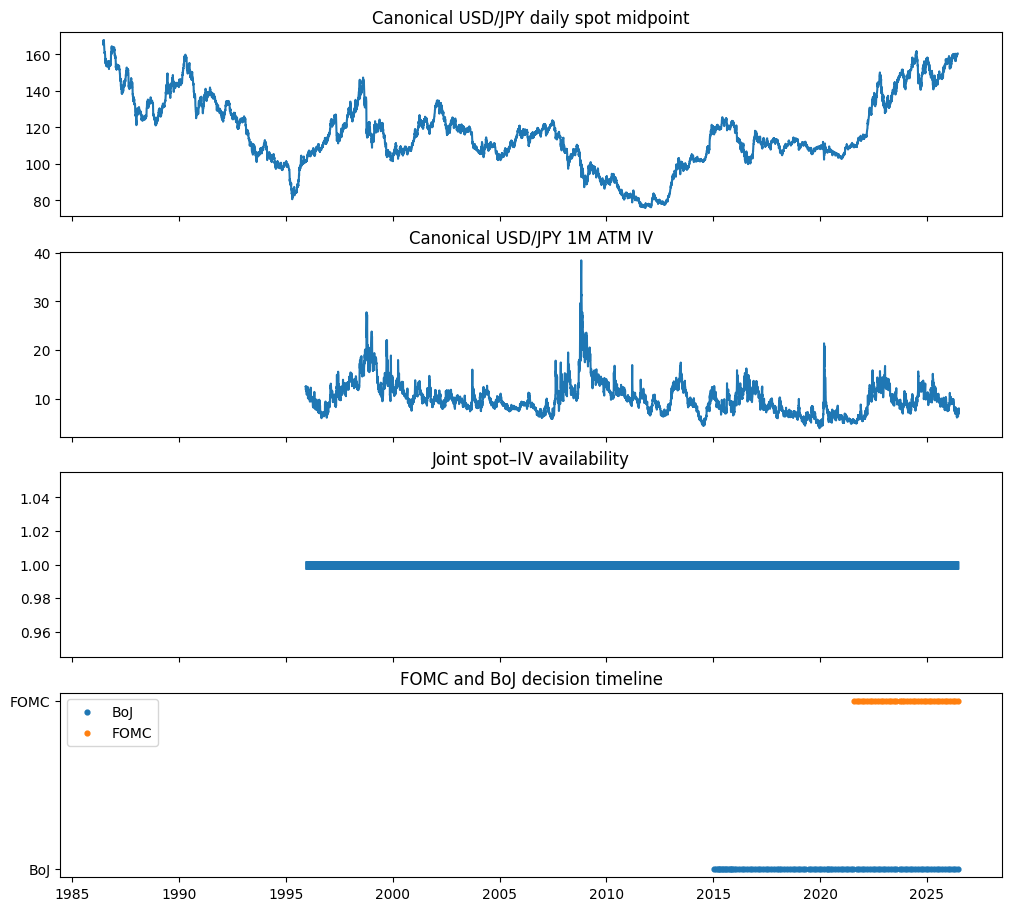

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True, constrained_layout=True)
axes[0].plot(spot['date'], spot['spot_mid'])
axes[0].set_title('Canonical USD/JPY daily spot midpoint')
axes[1].plot(a1['date'], a1['atm_1m_iv'])
axes[1].set_title('Canonical USD/JPY 1M ATM IV')
axes[2].plot(panel['date'], np.ones(len(panel)), '|')
axes[2].set_title('Joint spot–IV availability')
for bank, group in events.groupby('central_bank'):
    axes[3].scatter(group['local_event_date'], [bank] * len(group), label=bank, s=12)
axes[3].legend()
axes[3].set_title('FOMC and BoJ decision timeline')
plt.show()


### Combined visual-alignment diagnostic

This combined diagnostic displays the canonical daily USD/JPY spot midpoint and 1M ATM implied volatility over the event-supported period beginning in 2015. Cleaned BoJ and FOMC decision dates are marked to verify their temporal alignment with the market series before the formal event study in Notebook 15.

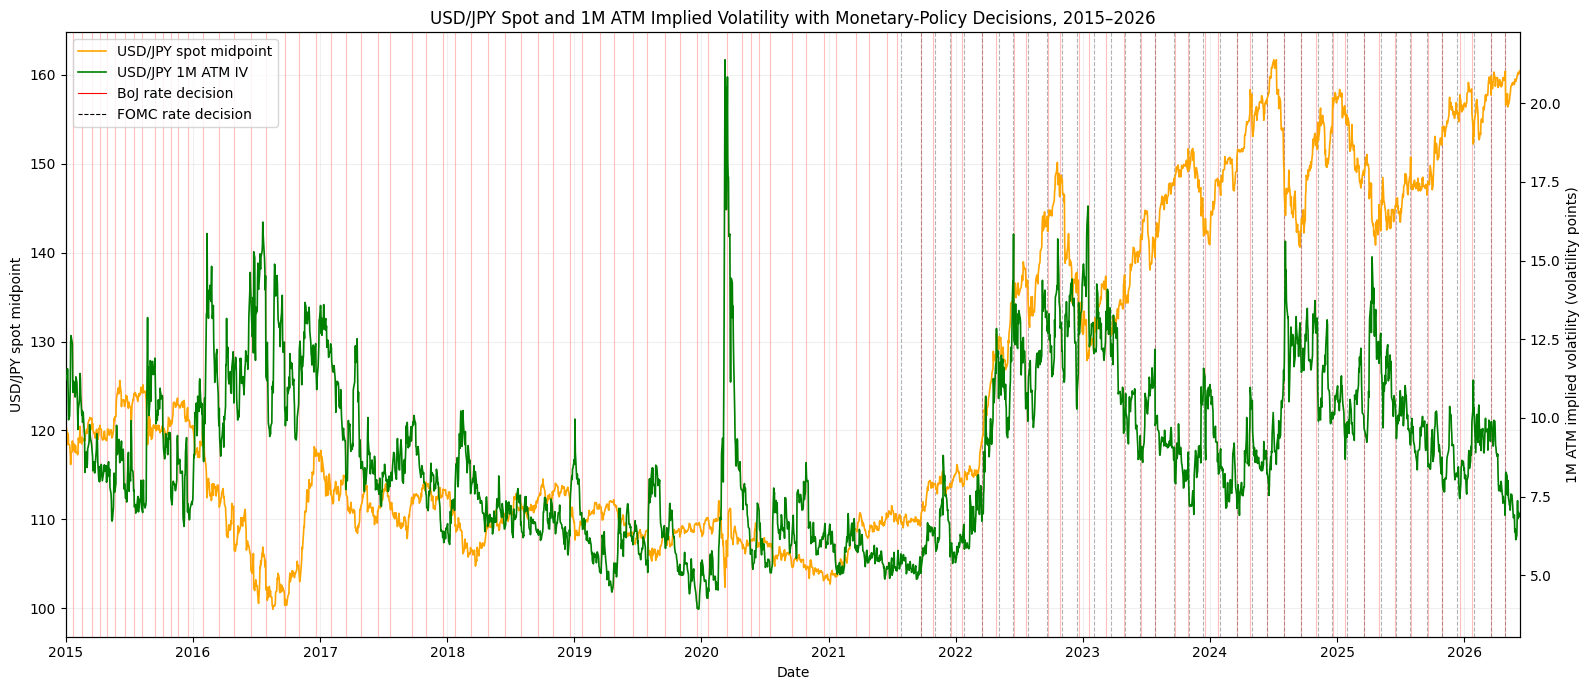

In [12]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

plot_start = pd.Timestamp('2015-01-01')
plot_end = panel['date'].max()
plot_panel = panel.loc[panel['date'].between(plot_start, plot_end)].copy()
panel_dates_in_plot = set(plot_panel['date'])
plot_events = events[['event_id', 'central_bank', 'local_event_date']].loc[
    events['local_event_date'].between(plot_start, plot_end)
    & events['local_event_date'].isin(panel_dates_in_plot)
].copy()
boj_plot_events = plot_events.loc[plot_events['central_bank'].eq('BoJ')]
fomc_plot_events = plot_events.loc[plot_events['central_bank'].eq('FOMC')]
boj_marker_count = len(boj_plot_events)
fomc_marker_count = len(fomc_plot_events)

assert plot_panel['date'].min() >= plot_start
assert plot_panel['date'].max() == panel['date'].max()
assert plot_panel['date'].max() == pd.Timestamp('2026-06-10')
assert plot_panel['spot_mid'].notna().any()
assert plot_panel['atm_1m_iv'].notna().any()
assert boj_marker_count == 98
assert fomc_marker_count == 39
assert plot_events['event_id'].is_unique
assert not plot_events['event_id'].isin(['BOJ_20150126', 'BOJ_20150223', 'BOJ_20160203']).any()
assert plot_events['local_event_date'].between(plot_start, plot_end).all()
assert len(panel) == 7922
assert panel['date'].max() == pd.Timestamp('2026-06-10')

fig, ax_spot = plt.subplots(figsize=(16, 7))
ax_iv = ax_spot.twinx()
spot_line, = ax_spot.plot(
    plot_panel['date'],
    plot_panel['spot_mid'],
    color='orange',
    linewidth=1.2,
    label='USD/JPY spot midpoint',
    zorder=3,
)
iv_line, = ax_iv.plot(
    plot_panel['date'],
    plot_panel['atm_1m_iv'],
    color='green',
    linewidth=1.2,
    label='USD/JPY 1M ATM IV',
    zorder=3,
)
for event_date in boj_plot_events['local_event_date']:
    ax_spot.axvline(event_date, color='red', linestyle='-', linewidth=0.8, alpha=0.25, zorder=1)
for event_date in fomc_plot_events['local_event_date']:
    ax_spot.axvline(event_date, color='black', linestyle='--', linewidth=0.8, alpha=0.30, zorder=1)

event_handles = [
    Line2D([0], [0], color='red', linestyle='-', linewidth=0.8, label='BoJ rate decision'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=0.8, label='FOMC rate decision'),
]
legend = ax_spot.legend(
    handles=[spot_line, iv_line, *event_handles],
    loc='upper left',
    frameon=True,
)
assert len(legend.get_texts()) == 4

ax_spot.set_title('USD/JPY Spot and 1M ATM Implied Volatility with Monetary-Policy Decisions, 2015–2026')
ax_spot.set_xlabel('Date')
ax_spot.set_ylabel('USD/JPY spot midpoint')
ax_iv.set_ylabel('1M ATM implied volatility (volatility points)')
ax_spot.grid(True, alpha=0.20)
ax_spot.set_xlim(plot_start, plot_end)
ax_spot.xaxis.set_major_locator(mdates.YearLocator())
ax_spot.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()


The two market series use separate y-axes because spot and implied volatility are measured in different units. The vertical markers represent cleaned local monetary-policy decision dates and are included as an alignment diagnostic only. Visual proximity between an event and a market movement does not establish causality.

The precise daily Bloomberg implied-volatility fixing time remains unknown. Notebook 15 therefore retains both the same-date and next-trading-observation alignment conventions.

## 14. Validation and exports

In [13]:
def id_count(value):
    return 0 if pd.isna(value) or value == '' else len(str(value).split(';'))

for window in [windows_same, windows_next]:
    sizes = window.groupby('event_id').size()
    assert sizes.eq(31).all()
    event_fields = [
        'complete_pre_window_flag', 'complete_post_window_flag', 'complete_window_flag',
        'other_decision_in_full_window_flag', 'other_decision_ids_full_window', 'other_decision_count_full_window',
        'other_decision_in_post_window_flag', 'other_decision_ids_post_window', 'other_decision_count_post_window',
        'same_bank_decision_in_full_window_flag', 'other_bank_decision_in_full_window_flag',
        'strict_clean_full_window_flag', 'clean_post_window_flag',
    ]
    assert window.groupby('event_id')[event_fields].nunique(dropna=False).eq(1).all().all()
    assert not (window['strict_clean_full_window_flag'] & window['other_decision_in_full_window_flag']).any()
    assert not (window['clean_post_window_flag'] & window['other_decision_in_post_window_flag']).any()
    assert window['other_decision_count_full_window'].eq(window['other_decision_ids_full_window'].map(id_count)).all()
    assert window['other_decision_count_post_window'].eq(window['other_decision_ids_post_window'].map(id_count)).all()

assert set(coverage_same['event_id']) == set(coverage_next['event_id'])
assert int(spot['spot_crossed_quote_flag'].sum()) == 12
assert short_1m_conflicts == 0
assert shorter_1m_exact_matches == 1305
assert five_year_conflicts == 1
assert total_secondary_atm_conflicts == 1
assert bf_1w_ticker == 'USDJPY25R1W BGN Curncy'

clean_summary = coverage.groupby(['alignment_convention', 'central_bank'], as_index=False).agg(
    events=('event_id', 'count'),
    full_window_contaminated=('other_decision_in_full_window_flag', 'sum'),
    post_window_contaminated=('other_decision_in_post_window_flag', 'sum'),
    strict_full_window_clean=('strict_clean_full_window_flag', 'sum'),
    post_window_clean=('clean_post_window_flag', 'sum'),
)
clean_counts = clean_summary.set_index(['alignment_convention', 'central_bank'])
for convention in ['same_date', 'next_observation']:
    assert clean_counts.loc[(convention, 'BoJ'), 'strict_full_window_clean'] == 46
    assert clean_counts.loc[(convention, 'BoJ'), 'post_window_clean'] == 76
    assert clean_counts.loc[(convention, 'FOMC'), 'strict_full_window_clean'] == 0
    assert clean_counts.loc[(convention, 'FOMC'), 'post_window_clean'] == 19

rec = pd.DataFrame([{
    'canonical_spot_source': P['spot'].name,
    'canonical_atm_source': P['atm'].name,
    'canonical_fomc_source': P['fomc'].name,
    'canonical_boj_source': P['boj'].name,
    'spot_columns': 'Dates; USDJPY PX_BID/PX_ASK/PX_LAST (H:J)',
    'atm_sheet_ticker': '1M; USDJPYV1M BGN Curncy',
    'iv_unit': 'volatility percentage points',
    'full_common_panel_start': panel['date'].min(),
    'full_common_panel_end': panel['date'].max(),
    'full_common_panel_observations': len(panel),
    'event_calendar_period': f"{inside_events['local_event_date'].min().date()} to {inside_events['local_event_date'].max().date()}",
    'usable_event_period': 'BoJ: 2015 onward; FOMC: 2021 onward',
    'common_bank_comparison_period': f'{common_start.date()} to {common_end.date()}',
    'boj_raw_rows': len(boj_raw),
    'boj_raw_decision_rows': len(boj_decision_raw),
    'boj_minutes_rows_excluded': len(boj_nondecision_raw),
    'boj_unique_cleaned_decisions': boj_clean['event_id'].nunique(),
    'boj_duplicate_decision_dates': duplicate_decision_date_count,
    'fomc_inside_panel': fomc_inside['event_id'].nunique(),
    'boj_inside_panel': boj_inside['event_id'].nunique(),
    'inside_panel_decisions_total': inside_events['event_id'].nunique(),
    'event_window_rows_same_date': len(windows_same),
    'event_window_rows_next_observation': len(windows_next),
    'common_period_fomc': common_counts['FOMC'],
    'common_period_boj': common_counts['BoJ'],
    'native_common_transition_mismatches': native_common_transition_mismatches,
    'crossed_quote_count': int(spot['spot_crossed_quote_flag'].sum()),
    'shorter_1m_common_dates': short_1m_reconciliation['common_dates'],
    'shorter_1m_exact_matches': shorter_1m_exact_matches,
    'shorter_1m_conflict_count': short_1m_conflicts,
    'five_year_atm_conflict_count': five_year_conflicts,
    'five_year_atm_conflicting_dates': five_year_reconciliation['conflicting_dates'],
    'secondary_atm_conflict_count': total_secondary_atm_conflicts,
    'bf_1w_anomaly': bf_1w_ticker,
    'event_contamination_summary': json.dumps(clean_summary.to_dict(orient='records')),
    'unresolved_issue': 'Daily Bloomberg IV fixing time unknown; retain both daily alignment conventions for Notebook 15.',
}])
rec.to_csv(OUT / 'canonical_source_recommendation.csv', index=False)

primary = {'spot', 'atm', 'rr', 'bf', 'fomc', 'boj'}
secondary_roles = {'mid', 'short', 'conflict'}
roles = {path.name: role for role, path in P.items()}
inventory_rows = []
for path in sorted(DATA.iterdir()):
    role = roles.get(path.name, 'not used')
    if role in primary:
        included, reason, status = True, '', 'loaded'
    elif role in secondary_roles:
        included, reason, status = False, 'secondary reconciliation source', 'loaded'
    else:
        included, reason, status = False, excluded.get(path.name, 'out of scope'), 'located'
    inventory_rows.append({'filename': path.name, 'extension': path.suffix, 'expected role': role, 'included': included, 'exclusion reason': reason, 'load status': status, 'warning': ''})
inventory = pd.DataFrame(inventory_rows)
inventory.to_csv(OUT / 'raw_file_inventory.csv', index=False)

required = {
    'raw_file_inventory.csv', 'usdjpy_spot_quality_audit.csv', 'usdjpy_atm_tidy.csv',
    'atm_source_reconciliation.csv', 'usdjpy_25d_rr_tidy.csv', 'usdjpy_25d_bf_tidy.csv',
    'option_source_anomalies.csv', 'fomc_decisions_clean.csv', 'boj_decisions_clean.csv', 'boj_event_type_audit.csv',
    'boj_duplicate_resolution.csv', 'central_bank_decisions_clean.csv', 'usdjpy_daily_spot_1m_atm_panel.csv',
    'event_alignment_same_date.csv', 'event_alignment_next_observation.csv', 'event_windows_same_date.csv',
    'event_windows_next_observation.csv', 'event_window_coverage.csv', 'canonical_source_recommendation.csv', 'manifest.json',
}
manifest = {
    'notebook_name': '14_real_data_audit_and_event_alignment.ipynb',
    'execution_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'source_files_read': [path.name for path in P.values()],
    'source_files_excluded': excluded,
    'canonical_choices': rec.iloc[0].to_dict(),
    'event_window_counts': clean_summary.to_dict(orient='records'),
    'boj_event_type_audit': boj_event_type_audit.to_dict(orient='records'),
    'boj_raw_rows': len(boj_raw),
    'boj_raw_decision_rows': len(boj_decision_raw),
    'boj_minutes_rows_excluded': len(boj_nondecision_raw),
    'boj_unique_cleaned_decisions': boj_clean['event_id'].nunique(),
    'boj_duplicate_decision_dates': duplicate_decision_date_count,
    'inside_panel_decisions_total': inside_events['event_id'].nunique(),
    'secondary_atm_reconciliation': reconciliation.to_dict(orient='records'),
    'total_secondary_atm_conflicts': total_secondary_atm_conflicts,
    'common_period_counts': common_counts,
    'native_common_transition_mismatches': native_common_transition_mismatches,
    'output_files': sorted(required),
    'raw_files_changed': False,
    'causal_analysis_or_forecasting_run': False,
    'unresolved_questions': [rec.iloc[0]['unresolved_issue']],
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, default=str, indent=2), encoding='utf-8')
assert required.issubset({path.name for path in OUT.iterdir()})

in_panel_boj_count = boj_inside['event_id'].nunique()
in_panel_fomc_count = fomc_inside['event_id'].nunique()
print(
    f'Panel: {len(panel):,}; BoJ raw/decisions/minutes: '
    f'{len(boj_raw)}/{len(boj_decision_raw)}/{len(boj_nondecision_raw)}; '
    f'in-panel BoJ/FOMC: {in_panel_boj_count}/{in_panel_fomc_count}'
)
display(clean_summary)


Panel: 7,922; BoJ raw/decisions/minutes: 108/105/3; in-panel BoJ/FOMC: 98/39


,alignment_convention,central_bank,events,full_window_contaminated,post_window_contaminated,strict_full_window_clean,post_window_clean
0,next_observation,BoJ,98,52,22,46,76
1,next_observation,FOMC,39,39,20,0,19
2,same_date,BoJ,98,52,22,46,76
3,same_date,FOMC,39,39,20,0,19


## 15. Findings and Notebook 15 handoff

The canonical sources are reliable because the primary USD/JPY spot and 1M ATM series are explicitly identified and independently audited; secondary IV files are reconciliation evidence only. Panel-based transformations prevent a source-native transition from silently crossing dates absent from the common panel. Both daily alignment conventions are retained because the IV fixing time is not known. Full-window and post-window contamination answer different questions, so both are reported; contamination is recorded rather than used to delete events. Direct FOMC-versus-BoJ comparisons must use the common 2021–2026 period, while the earlier BoJ history is for BoJ-only analysis. This notebook produces no causal or forecasting findings.